# Detecting Structural Distress at Scale
### A Geospatial Foundation Model Approach to Urban Building Safety

**Course:** MUSA 6500 â€“ Geospatial Machine Learning in Remote Sensing  
**Authors:** Jason Fan, Henry Sywulak-Herr

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Environment setup & imports |
| 2 | Data loading (imagery, footprints, labels, elevation) |

---
## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import show as rshow

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

# â”€â”€ Add project root to path so loader scripts are importable â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PROJECT_ROOT = Path('.').resolve()   # adjust if notebook is in a sub-folder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Device: cuda
  GPU: Tesla T4
Project root: /content


In [2]:
# -- Colab runtime setup (deps + Drive mount + sys.path) ---------------------
import sys, os, subprocess

IS_COLAB = os.path.exists('/content')

if IS_COLAB:
    # Install deps that aren't pre-installed on the Colab image
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q',
        'git+https://github.com/Clay-foundation/model.git',
        'rioxarray', 'geopandas', 'tqdm',
    ], check=True)

    from google.colab import drive
    drive.mount('/content/drive')

    # Folder on Drive that contains load_imagery.py, load_labels.py, etc.
    DRIVE_FOLDER = '/content/drive/MyDrive/folder'
    if DRIVE_FOLDER not in sys.path:
        sys.path.insert(0, DRIVE_FOLDER)

    DRIVE_BASE = Path(DRIVE_FOLDER)
    print(f'Drive mounted. Project folder: {DRIVE_FOLDER}')
else:
    DRIVE_BASE = PROJECT_ROOT
    print('Running locally.')

CHIP_DIR = DRIVE_BASE / 'data' / 'chips'
CHIP_DIR.mkdir(parents=True, exist_ok=True)


Mounted at /content/drive
Drive mounted. Project folder: /content/drive/MyDrive/folder


---
## 2. Data Loading

Each dataset is loaded via its own dedicated module.  

### Imagery

In [3]:
import sys, os
# Make sure project scripts are on the path wherever the file lives
for _p in [os.getcwd(), '/content/drive/MyDrive/folder', '/content', '/content/musa6500-finalproject']:
    if os.path.exists(os.path.join(_p, 'load_imagery.py')) and _p not in sys.path:
        sys.path.insert(0, _p)
        break

from load_imagery import open_imagery

# This creates a lazy DataArray backed by the remote Cloud Optimized GeoTIFF (COG)
src = open_imagery()

[load_imagery] Opened: https://musa-650.s3.amazonaws.com/phl_aerial_0.3m.tif
  CRS   : EPSG:2272
  Shape : (3, 123383, 109972)  (bands × rows × cols)
  Res   : (0.984252, -0.984252) (x_res, y_res)


### Parcels & Permits

In [4]:
from load_building_footprints import load_building_footprints, fetch_geojson
from pathlib import Path

VECTOR_DIR = Path('data/vector')
CRS = 'EPSG:2272'

# PWD parcels (primary geometry for all spatial joins)
parcels = load_building_footprints()
print(f'Parcels: {len(parcels):,}')

# eCLIPSE permits â€“ used to filter false positives (new construction)
PERMIT_URL = 'https://hub.arcgis.com/api/v3/datasets/8d18914ff740444793937d8724c64da8_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1'
permits = fetch_geojson('permits', PERMIT_URL, VECTOR_DIR).to_crs(CRS)
print(f'Permits: {len(permits):,}')

[load_building_footprints] Fetching parcels from https://opendata.arcgis.com/datasets/84baed491de44f539889f2af178ad85c_0.geojson ...
  → cached to data/vector/parcels.geojson
[load_building_footprints] Geometry cleaning: 547,290 → 547,280 parcels
[load_building_footprints] Parcels loaded: 547,280 | CRS: EPSG:2272
Parcels: 547,280
[load_building_footprints] Fetching permits from https://hub.arcgis.com/api/v3/datasets/8d18914ff740444793937d8724c64da8_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1 ...
  → cached to data/vector/permits.geojson
Permits: 13,936


### Training Labels (L&I Violations)

Fetching imm_dang...
[load_labels] Fetching imm_dang from Carto API...
  → cached to data/labels/imm_dang.geojson
  rows: 142
Fetching unsafe...
[load_labels] Fetching unsafe from Carto API...
  → cached to data/labels/unsafe.geojson
  rows: 2,638
Fetching clean_seal...
[load_labels] Fetching clean_seal from Carto API...
  → cached to data/labels/clean_seal.geojson
  rows: 8,596
Labeled Imminently Dangerous : 139
Labeled Unsafe               : 7,815
Labeled Stable               : 539,326


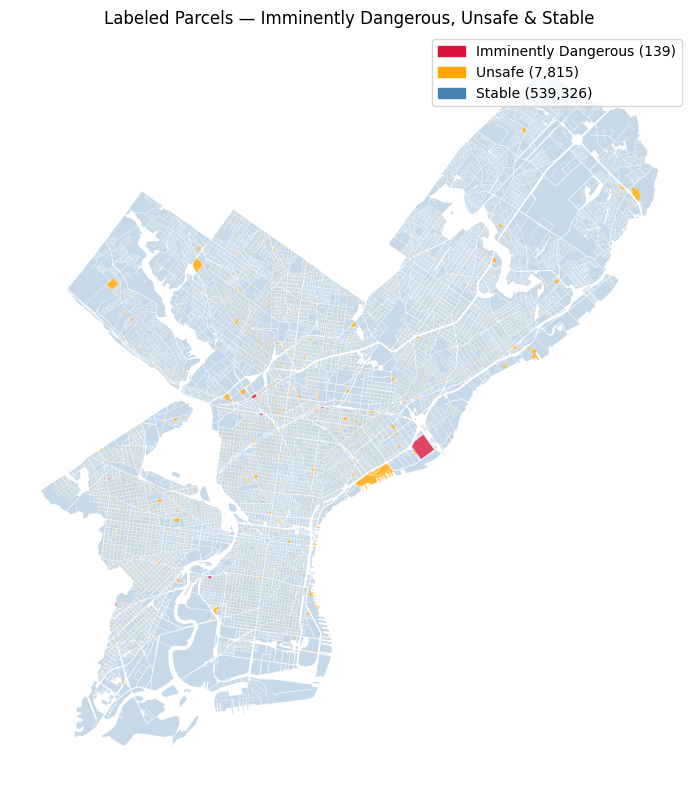

In [5]:
import importlib
import load_labels
importlib.reload(load_labels)

from load_labels import load_labels, plot_labels

parcels_labeled = load_labels(parcels, permits=permits)

plot_labels(parcels_labeled)

Labeled Imminently Dangerous : 136
Labeled Unsafe               : 7,794
Labeled Stable               : 539,360

"Imminently dangerous" is too small of a sample for the deep learning model to learn distinct classes. Will be merging unsafe and ID into a single "distressed" class. 

### Create balanced df

In [6]:
import pandas as pd

# 1. Isolate all the minority class parcels (Unsafe and Imminently Dangerous)
distressed_parcels = parcels_labeled[parcels_labeled['label'].isin([1, 2])].copy()

# 2. Randomly sample the "Stable" (0) class. 
# Let's take twice as many Stable as Distressed (a 2:1 ratio is a good starting point)
num_distressed = len(distressed_parcels)
num_stable_to_keep = num_distressed * 2

print(f"Keeping {num_distressed} distressed parcels and {num_stable_to_keep} stable parcels.")

# Sample from the stable parcels
stable_parcels = parcels_labeled[parcels_labeled['label'] == 0].sample(
    n=num_stable_to_keep, 
    random_state=42 # Set random state for reproducibility
).copy()

# 3. Combine them and shuffle the dataset
balanced_parcels = pd.concat([distressed_parcels, stable_parcels])
balanced_parcels = balanced_parcels.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nNew Balanced Label Counts:")
print(balanced_parcels['label'].value_counts())

Keeping 7954 distressed parcels and 15908 stable parcels.

New Balanced Label Counts:
label
0    15908
1     7815
2      139
Name: count, dtype: int64


Label merge

In [7]:
# Map Imminently Dangerous (2) to Unsafe/Distressed (1)
balanced_parcels['label'] = balanced_parcels['label'].replace({2: 1})

print("Final Binary Label Counts (0=Stable, 1=Distressed):")
print(balanced_parcels['label'].value_counts())

Final Binary Label Counts (0=Stable, 1=Distressed):
label
0    15908
1     7954
Name: count, dtype: int64


In [8]:
# Saves balanced_parcels so Colab can load it from Drive
out = (DRIVE_BASE / 'data' / 'balanced_parcels.geojson') if IS_COLAB else Path('data/balanced_parcels.geojson')
out.parent.mkdir(parents=True, exist_ok=True)
balanced_parcels[["geometry", "label"]].to_file(out, driver="GeoJSON")
print(f"Saved: {out}")

Saved: /content/drive/MyDrive/folder/data/balanced_parcels.geojson


### Focal Loss:

weighted cross entropy is the standard fix but focal loss is better for is our model struggles to recognize the visual signs of decay. 

In [9]:
import torch.nn.functional as F

# Binary classification: single logit head + BCEWithLogitsLoss.
#
# Dataset is already 2:1 stable:distressed by construction (cell 13 down-samples
# stable). Stacking pos_weight=2.0 on top of that double-counts the minority
# class and pushed the model into 59% predicted-positive (way above the 33%
# prior). pos_weight=1.0 lets the loss reflect the actual sampled distribution
# and the model has to discriminate rather than lean on a tilted prior.
POS_WEIGHT = torch.tensor([1.0], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)


### Image augmentation 
this helps oversample the distressed buildings 

In [10]:
import torchvision.transforms.v2 as Tv2

# Tensor-in / tensor-out. Resize + pad happens inside ParcelDataset so we can
# preserve aspect ratio; here we only do augmentations on a [3, 224, 224] float
# tensor in [0, 1].
train_transforms = Tv2.Compose([
    Tv2.RandomHorizontalFlip(p=0.5),
    Tv2.RandomVerticalFlip(p=0.5),
    Tv2.RandomRotation(degrees=180),
    Tv2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

# No augmentation at val time
val_transforms = None


pytorch dataset class

In [11]:
from load_imagery import read_parcel_chip
import torch.nn.functional as F

IMAGE_SIZE = 224  # Clay v1.5 expects 224x224 inputs

# Clay v1.5 NAIP RGB stats (from claymodel metadata.yaml). Closest match to
# Philadelphia 0.3 m aerial. Frozen encoder produces near-constant CLS
# embeddings on un-normalized [0,1] input, which starves the head.
CLAY_RGB_MEAN = torch.tensor([110.16, 115.41,  98.15]).view(3, 1, 1) / 255.0
CLAY_RGB_STD  = torch.tensor([ 47.23,  39.82,  35.43]).view(3, 1, 1) / 255.0


def _pad_to_square_and_resize(arr: np.ndarray, size: int = IMAGE_SIZE) -> torch.Tensor:
    """arr: float32 [3, H, W] in [0, 1] -> [3, size, size] with aspect ratio preserved."""
    t = torch.from_numpy(arr)
    _, H, W = t.shape
    side = max(H, W)
    pad_h, pad_w = side - H, side - W
    t = F.pad(t, (pad_w // 2, pad_w - pad_w // 2,
                  pad_h // 2, pad_h - pad_h // 2), value=0.0)
    t = F.interpolate(t.unsqueeze(0), size=(size, size),
                      mode='bilinear', align_corners=False).squeeze(0)
    return t


class ParcelDataset(Dataset):
    def __init__(self, gdf, imagery_src, transform=None):
        # Do NOT reset_index — chip filenames use the original balanced_parcels index.
        self.gdf = gdf
        self.src = imagery_src
        self.transform = transform

    def __len__(self):
        return len(self.gdf)

    def __getitem__(self, idx):
        row = self.gdf.iloc[idx]
        label = int(row.label)
        chip_id = row.name

        chip_path = CHIP_DIR / f"{chip_id}.npy"
        try:
            arr = np.load(chip_path).astype(np.float32)   # [3, H, W], raw 0–255
            arr = np.clip(arr / 255.0, 0.0, 1.0)
        except Exception:
            arr = np.zeros((3, IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)

        img = _pad_to_square_and_resize(arr, size=IMAGE_SIZE)  # [3, 224, 224]

        if self.transform is not None:
            img = self.transform(img)

        # Clay normalization — apply AFTER augmentation so flips/rotations
        # still operate on a [0,1] image.
        img = (img - CLAY_RGB_MEAN) / CLAY_RGB_STD

        return img, torch.tensor(label, dtype=torch.long)

Helper function:

In [12]:
from torch.utils.data import DataLoader

def create_dataloaders(train_gdf, val_gdf, src, train_tfm, val_tfm, batch_size=32):
    """Creates and returns a dictionary of train and val dataloaders."""
    datasets = {
        'train': ParcelDataset(train_gdf, src, transform=train_tfm),
        'val': ParcelDataset(val_gdf, src, transform=val_tfm)
    }
    loaders = {
        'train': DataLoader(datasets['train'], batch_size=batch_size, shuffle=True, drop_last=True),
        'val': DataLoader(datasets['val'], batch_size=batch_size, shuffle=False)
    }
    return loaders

train/validation split

In [13]:
# --- Create a new cell for DataLoaders ---
from sklearn.model_selection import train_test_split

# Split the data (80% Train, 20% Validation)
# stratify=True ensures the 2:1 ratio is preserved in both sets
train_gdf, val_gdf = train_test_split(
    balanced_parcels,
    test_size=0.2,
    random_state=SEED,
    stratify=balanced_parcels['label']
)

print(f"Training parcels: {len(train_gdf)}")
print(f"Validation parcels: {len(val_gdf)}")

# Instantiate Datasets
train_dataset = ParcelDataset(train_gdf, src, transform=train_transforms)
val_dataset = ParcelDataset(val_gdf, src, transform=val_transforms)

# Create DataLoaders (Batches)
BATCH_SIZE = 64 if DEVICE == 'cuda' else 32

# num_workers=0 keeps everything in the main process. Worker subprocesses
# crash on Colab because the rioxarray `src` (a lazy DataArray over a remote
# COG) can't be pickled into the worker, and Colab's /dev/shm is too small
# for pin_memory + persistent_workers anyway. Chips are local .npy files so
# loading is fast in-process.
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'),
)

# Quick test to make sure the pipeline works
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}") # Should be [64, 3, 224, 224]
print(f"Batch label shape: {labels.shape}") # Should be [64]


Training parcels: 19089
Validation parcels: 4773
Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])


CLAY model

download checkpoint

In [14]:
import urllib.request
from pathlib import Path

CKPT_PATH = DRIVE_BASE / "data" / "clay-v1.5.ckpt"
CKPT_URL  = "https://huggingface.co/made-with-clay/Clay/resolve/main/v1.5/clay-v1.5.ckpt"

if not CKPT_PATH.exists():
    CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading Clay v1.5 checkpoint (~3 GB)â€¦")
    urllib.request.urlretrieve(CKPT_URL, CKPT_PATH)
    print(f"Saved to {CKPT_PATH}")
else:
    print(f"Checkpoint already exists: {CKPT_PATH}")

Checkpoint already exists: /content/drive/MyDrive/folder/data/clay-v1.5.ckpt


build the classifer

In [15]:
import re
import torch
import torch.nn as nn
from claymodel.model import Encoder

# â”€â”€ RGB wavelengths (micrometers) for Philadelphia aerial imagery â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
RGB_WAVES = torch.tensor([0.665, 0.560, 0.493])   # R, G, B
RGB_GSD   = torch.tensor(0.3)                      # Philadelphia aerial ~0.3 m

class ClayDistressClassifier(nn.Module):
    """
    Clay v1.5 large encoder (frozen) + 2-class MLP head.
    Mirrors claymodel/finetune/classify/factory.py but wired for 3-band
    aerial RGB instead of 10-band Sentinel-2.
    """
    def __init__(self, num_classes=2, ckpt_path=None):
        super().__init__()

        # Clay large encoder â€” mask_ratio=0, shuffle=False for inference/fine-tune
        self.encoder = Encoder(
            mask_ratio=0.0,
            patch_size=8,
            shuffle=False,
            dim=1024,
            depth=24,
            heads=16,
            dim_head=64,
            mlp_ratio=4.0,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(1024),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, num_classes),
        )

        if ckpt_path:
            self._load_clay_weights(ckpt_path)

    def _load_clay_weights(self, ckpt_path):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(ckpt_path, map_location=device)
        state_dict = ckpt.get("state_dict", ckpt)

        # Strip the "model.encoder." prefix used in the Lightning checkpoint
        encoder_sd = {
            re.sub(r"^model\.encoder\.", "", k): v
            for k, v in state_dict.items()
            if k.startswith("model.encoder")
        }

        missing = []
        for name, param in self.encoder.named_parameters():
            if name in encoder_sd and param.size() == encoder_sd[name].size():
                param.data.copy_(encoder_sd[name])
            else:
                missing.append(name)

        if missing:
            print(f"  [warn] {len(missing)} encoder params not loaded: {missing[:5]}â€¦")
        else:
            print("  Clay encoder weights loaded successfully.")

        # Freeze encoder â€” only the head trains
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.encoder.eval()

    def forward(self, pixels):
        B = pixels.shape[0]
        device = pixels.device

        datacube = {
            "pixels": pixels,
            "time":   torch.zeros(B, 4, device=device),
            "latlon": torch.zeros(B, 4, device=device),
            "gsd":    RGB_GSD.to(device),
            "waves":  RGB_WAVES.to(device),
        }

        embeddings, *_ = self.encoder(datacube)   # [B, 1+patches, 1024]
        patch_tokens   = embeddings[:, 1:, :]     # drop the conditioning token
        pooled         = patch_tokens.mean(dim=1) # [B, 1024]
        return self.head(pooled)


model = ClayDistressClassifier(num_classes=2, ckpt_path=CKPT_PATH).to(DEVICE)
print(model)
print(f"\nTrainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Frozen params:    {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

  Clay encoder weights loaded successfully.
ClayDistressClassifier(
  (encoder): Encoder(
    (patch_embedding): DynamicEmbedding(
      (weight_generator): WavesTransformer(
        (encoder): TransformerEncoder(
          (layers): ModuleList(
            (0): TransformerEncoderLayer(
              (self_attn): MultiheadAttention(
                (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
              )
              (linear1): Linear(in_features=128, out_features=2048, bias=True)
              (dropout): Dropout(p=0, inplace=False)
              (linear2): Linear(in_features=2048, out_features=128, bias=True)
              (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (dropout1): Dropout(p=0, inplace=False)
              (dropout2): Dropout(p=0, inplace=False)
            )
          )
        )
        (fc_weight): Linear(in_fea

Pre-cache to disk

In [16]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

CHIP_DIR = DRIVE_BASE / "data" / "chips"
CHIP_DIR.mkdir(parents=True, exist_ok=True)

def precache_chips(gdf, src, chip_dir=CHIP_DIR):
    """Clip and save every parcel chip once. Skips already-saved chips."""
    for idx, row in tqdm(gdf.iterrows(), total=len(gdf), desc="Caching chips"):
        out = chip_dir / f"{idx}.npy"
        if out.exists():
            continue
        try:
            chip = read_parcel_chip(src, row.geometry)
            arr = chip.values[:3, :, :].astype(np.float32)
            np.save(out, arr)
        except Exception:
            np.save(out, np.zeros((3, 64, 64), dtype=np.float32))

precache_chips(balanced_parcels, src)

Caching chips: 100%|██████████| 23862/23862 [00:06<00:00, 3816.98it/s]


train loop

In [18]:
import os
from pathlib import Path

DRIVE_TAR = Path("/content/drive/MyDrive/folder/data/chips.tar")
LOCAL_TAR = Path("/content/chips.tar")
LOCAL_CHIPS = Path("/content/chips_local")

if not DRIVE_TAR.exists():
    # Bundle once from the slow Drive directory into a tarball on local disk
    !tar -cf {LOCAL_TAR} -C /content/drive/MyDrive/folder/data chips
    # Copy the tarball back to Drive for persistence
    !cp {LOCAL_TAR} {DRIVE_TAR}
    print(f"Saved tarball to {DRIVE_TAR}")
else:
    print(f"Tarball already on Drive: {DRIVE_TAR}")

tar: chips/22862.npy: file changed as we read it
tar: chips/22863.npy: file changed as we read it
tar: chips/22864.npy: file changed as we read it
tar: chips/22865.npy: file changed as we read it
tar: chips/22866.npy: file changed as we read it
tar: chips/22867.npy: file changed as we read it
tar: chips/22868.npy: file changed as we read it
tar: chips/22869.npy: file changed as we read it
tar: chips/22870.npy: file changed as we read it
tar: chips/22871.npy: file changed as we read it
tar: chips/22872.npy: file changed as we read it
tar: chips/22873.npy: file changed as we read it
tar: chips/22874.npy: file changed as we read it
tar: chips/22875.npy: file changed as we read it
tar: chips/22876.npy: file changed as we read it
tar: chips/22877.npy: file changed as we read it
tar: chips/22878.npy: file changed as we read it
tar: chips/22879.npy: file changed as we read it
tar: chips/22880.npy: file changed as we read it
tar: chips/22881.npy: file changed as we read it
tar: chips/22882.npy

In [17]:
import os
from pathlib import Path

DRIVE_TAR = Path("/content/drive/MyDrive/folder/data/chips.tar")
LOCAL_CHIPS = Path("/content/chips_local")

if not LOCAL_CHIPS.exists():
    !tar -xf {DRIVE_TAR} -C /content/ && mv /content/chips /content/chips_local
    print(f"Extracted to {LOCAL_CHIPS}")

CHIP_DIR = LOCAL_CHIPS
print(f"CHIP_DIR={CHIP_DIR}, {len(list(CHIP_DIR.glob('*.npy'))):,} files")

Extracted to /content/chips_local
CHIP_DIR=/content/chips_local, 23,862 files


In [18]:
model.eval()
with torch.no_grad():
    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(DEVICE)
    feats = model.encoder({
        "pixels": imgs,
        "time":   torch.zeros(imgs.size(0), 4, device=DEVICE),
        "latlon": torch.zeros(imgs.size(0), 4, device=DEVICE),
        "gsd":    RGB_GSD.to(DEVICE),
        "waves":  RGB_WAVES.to(DEVICE),
    })[0]
    patch_mean = feats[:, 1:, :].mean(dim=1)   # [B, 1024]
    print(f"feat mean={patch_mean.mean():.3f}  "
          f"std_within_sample={patch_mean.std(dim=1).mean():.3f}  "
          f"std_across_batch={patch_mean.std(dim=0).mean():.4f}")

feat mean=0.004  std_within_sample=0.144  std_across_batch=0.0185


In [19]:
import math
from sklearn.metrics import recall_score, precision_score, classification_report

# ── Sanity check: confirm chip files line up with train_gdf indices ─────
sample_ids = list(train_gdf.index[:500])
loaded  = sum((CHIP_DIR / f"{i}.npy").exists() for i in sample_ids)
missing = len(sample_ids) - loaded
print(f"Chip cache check: loaded={loaded}, missing={missing} (out of {len(sample_ids)})")
assert missing == 0, "Chip cache mismatch — re-run the precache_chips cell."

for cls in (0, 1):
    sub = train_gdf[train_gdf['label'] == cls].iloc[0:1]
    ds  = ParcelDataset(sub, src, transform=None)
    img, lbl = ds[0]
    print(f"  class={lbl.item()}  shape={tuple(img.shape)}  "
          f"min={img.min():.3f}  max={img.max():.3f}  mean={img.mean():.3f}")

# ── Replace head with a single-logit binary classifier ──────────────────
model.head = nn.Sequential(
    nn.LayerNorm(1024),
    nn.Linear(1024, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(256, 1),
).to(DEVICE)

prior = float(train_gdf['label'].mean())
nn.init.constant_(model.head[-1].bias, math.log(prior / (1 - prior)))
print(f"Head initialised with bias = logit({prior:.3f}) = {math.log(prior/(1-prior)):.3f}")

# ── Unfreeze the top 4 encoder transformer layers for fine-tuning ───────
NUM_ENCODER_LAYERS = len(model.encoder.transformer.layers)
UNFREEZE_FROM = NUM_ENCODER_LAYERS - 4
for i, layer in enumerate(model.encoder.transformer.layers):
    requires = (i >= UNFREEZE_FROM)
    for p in layer.parameters():
        p.requires_grad = requires

optimizer = torch.optim.AdamW([
    {"params": [p for p in model.encoder.parameters() if p.requires_grad], "lr": 1e-5},
    {"params": model.head.parameters(),                                     "lr": 3e-4},
], weight_decay=1e-2)

NUM_EPOCHS = 20
THRESHOLD  = 0.33              # ← was 0.5; prior is 0.333
USE_AMP    = False             # ← flip to True once you've confirmed learning
best_recall = 0.0

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-5, 3e-4],
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}  |  AMP={USE_AMP}  |  threshold={THRESHOLD}")

for epoch in range(NUM_EPOCHS):
    # ── Train ───────────────────────────────────────────────────────────
    model.train()
    model.encoder.eval()
    for i, layer in enumerate(model.encoder.transformer.layers):
        if i >= UNFREEZE_FROM:
            layer.train()

    train_loss = 0.0
    for images, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=USE_AMP):
            logits = model(images)
            loss   = criterion(logits, labels)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()
        train_loss += loss.item()

    # ── Validate ────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            with torch.autocast(device_type='cuda', dtype=torch.float16,
                                enabled=USE_AMP):
                probs = torch.sigmoid(model(images)).squeeze(1).float()
            preds = (probs > THRESHOLD).long()
            all_probs.extend(probs.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.tolist())

    recall    = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
    precision = precision_score(all_labels, all_preds, pos_label=1, zero_division=0)
    pos_rate  = sum(all_preds) / len(all_preds)

    flag = ""
    if pos_rate > 0.75: flag = "  ⚠️  collapsing positive"
    if pos_rate < 0.10: flag = "  ⚠️  collapsing negative"

    print(f"Epoch {epoch+1:02d} | loss {train_loss/len(train_loader):.4f} "
          f"| recall {recall:.3f} | precision {precision:.3f} "
          f"| pos_rate {pos_rate:.2f}{flag}")

    if recall > best_recall and 0.10 < pos_rate < 0.75:
        best_recall = recall
        torch.save(model.state_dict(), DRIVE_BASE / "data" / "best_model.pt")
        print(f"  → saved (best recall so far: {best_recall:.3f})")

print("\nFinal validation report:")
print(classification_report(all_labels, all_preds, target_names=["Stable", "Distressed"]))

Chip cache check: loaded=500, missing=0 (out of 500)
  class=0  shape=(3, 224, 224)  min=-2.898  max=2.514  mean=-1.790
  class=1  shape=(3, 224, 224)  min=-2.898  max=3.572  mean=-1.982
Head initialised with bias = logit(0.333) = -0.693
Trainable params: 51,026,945  |  AMP=False  |  threshold=0.33


OutOfMemoryError: CUDA out of memory. Tried to allocate 198.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 129.81 MiB is free. Including non-PyTorch memory, this process has 14.43 GiB memory in use. Of the allocated memory 14.11 GiB is allocated by PyTorch, and 201.90 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

load best model and run final evals

In [20]:
model.load_state_dict(torch.load(DRIVE_BASE / "data" / "best_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        probs = torch.sigmoid(model(images)).squeeze(1)  # prob of Distressed
        preds = (probs > 0.5).long()
        all_probs.extend(probs.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(all_labels, all_preds, target_names=["Stable", "Distressed"]))

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=["Stable", "Distressed"],
    cmap="Blues"
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 14.39 GiB is allocated by PyTorch, and 42.50 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

if recall for distressed is below 0.90, lower threshold:

In [ ]:
# Threshold sweep on the saved validation probabilities.
# No retraining — just pick the operating point that balances recall/precision
# for your use case. For a distress-detection workflow, F1 is a reasonable
# default; if missing a distressed building is worse than a false alarm, bias
# toward higher recall (= lower threshold).
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

probs  = np.asarray(all_probs)
labels = np.asarray(all_labels)

precisions, recalls, thresholds = precision_recall_curve(labels, probs)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best = f1s[:-1].argmax()  # last element has no threshold
print(f"Best-F1 threshold: {thresholds[best]:.3f}  "
      f"(P={precisions[best]:.3f}, R={recalls[best]:.3f}, F1={f1s[best]:.3f})")
print()
print(f"{'thr':>5}  {'recall':>7}  {'precision':>9}  {'f1':>6}  {'pos_rate':>8}")
for thr in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]:
    preds = (probs > thr).astype(int)
    tp = int(((preds == 1) & (labels == 1)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())
    rec  = tp / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    pos  = preds.mean()
    print(f"{thr:5.2f}  {rec:7.3f}  {prec:9.3f}  {f1:6.3f}  {pos:8.2f}")

# Full classification report at the best-F1 threshold
threshold = float(thresholds[best])
preds_tuned = (probs > threshold).astype(int)
print(f"\n--- Classification report at threshold = {threshold:.3f} ---")
print(classification_report(labels, preds_tuned, target_names=["Stable", "Distressed"]))


Geographic stratification

In [ ]:
# Philly neighborhoods — Azavea's canonical layer (the OpenData ArcGIS URL
# returns 400 now). Column with the neighborhood name is `name`.
HOOD_URL = "https://raw.githubusercontent.com/azavea/geo-data/master/Neighborhoods_Philadelphia/Neighborhoods_Philadelphia.geojson"
hoods = gpd.read_file(HOOD_URL).to_crs("EPSG:2272")
print(f"Loaded {len(hoods)} neighborhoods. Columns: {list(hoods.columns)}")
print(f"Sample names: {hoods['name'].head(10).tolist()}")

# Broad regions per the README (North / South / West).
# NOTE: fill these lists out from the printout above — the `...` placeholders
# below were literal Ellipsis objects and would never match anything.
REGION_MAP = {
    "NORTH": [
        "Kensington", "Frankford", "Olney", "Logan", "Hunting Park",
        "Fairhill", "Feltonville", "Juniata Park", "Strawberry Mansion",
        "North Central", "Brewerytown", "Fishtown",
    ],
    "SOUTH": [
        "South Philadelphia", "Passyunk Square", "Point Breeze",
        "Pennsport", "Grays Ferry", "Whitman", "Girard Estates",
    ],
    "WEST":  [
        "West Philadelphia", "Cobbs Creek", "Overbrook", "Mantua",
        "Mill Creek", "Powelton Village", "Belmont", "Haddington",
    ],
}

val_gdf_copy = val_gdf.copy().reset_index(drop=True)
val_gdf_copy["pred"]  = all_preds
val_gdf_copy["label"] = all_labels

val_with_hood = gpd.sjoin(val_gdf_copy, hoods[["geometry", "name"]], how="left")

for region, neighborhoods in REGION_MAP.items():
    mask = val_with_hood["name"].isin(neighborhoods)
    sub = val_with_hood[mask]
    if len(sub) == 0:
        print(f"{region:6s} | no parcels matched — check neighborhood names")
        continue
    r = recall_score(sub["label"], sub["pred"], pos_label=1, zero_division=0)
    p = precision_score(sub["label"], sub["pred"], pos_label=1, zero_division=0)
    print(f"{region:6s} | n={len(sub):4d} | recall={r:.3f} | precision={p:.3f}")


Inference on the full city

In [ ]:
full_dataset = ParcelDataset(parcels_labeled, src, transform=val_transforms)
full_loader  = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

model.eval()
all_probs_full = []

with torch.no_grad():
    for i, (images, _) in enumerate(full_loader):
        images = images.to(DEVICE)
        probs = torch.sigmoid(model(images)).squeeze(1)
        all_probs_full.extend(probs.cpu().tolist())
        if i % 100 == 0:
            print(f"  {i * 64:,} / {len(parcels_labeled):,} parcels scored")

parcels_labeled["distress_score"] = all_probs_full
parcels_labeled["pred_distressed"] = (parcels_labeled["distress_score"] > threshold).astype(int)

print(parcels_labeled["pred_distressed"].value_counts())


apply permit filter

In [ ]:
# Zero out predictions where an active eCLIPSE permit exists
parcels_labeled.loc[parcels_labeled["label_permit_flagged"], "pred_distressed"] = 0

print("After permit filter:")
print(parcels_labeled["pred_distressed"].value_counts())

export and map

In [ ]:
from pathlib import Path

out_path = Path("output/predictions.geojson")
out_path.parent.mkdir(exist_ok=True)

parcels_labeled[["geometry", "parcel_id", "distress_score", "pred_distressed", "label"]].to_file(
    out_path, driver="GeoJSON"
)
print(f"Saved {out_path}")

# Quick map of top predicted-distressed parcels
fig, ax = plt.subplots(figsize=(10, 10))
parcels_labeled[parcels_labeled["pred_distressed"] == 0].plot(
    ax=ax, color="steelblue", alpha=0.2, linewidth=0
)
parcels_labeled[parcels_labeled["pred_distressed"] == 1].plot(
    ax=ax, column="distress_score", cmap="YlOrRd", linewidth=0, legend=True
)
ax.set_title("Predicted Structurally Distressed Parcels â€” Philadelphia")
ax.set_axis_off()
plt.tight_layout()
plt.show()